<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_069_hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 69/365 — Hierarchical Clustering

Hierarchical clustering builds a **tree of clusters** rather than directly returning only one final grouping.

The most common form is **Agglomerative Clustering**:

`individual points → small clusters → larger clusters`

The hierarchy is visualized using a **dendrogram**.


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram


## 1. Create unlabeled data


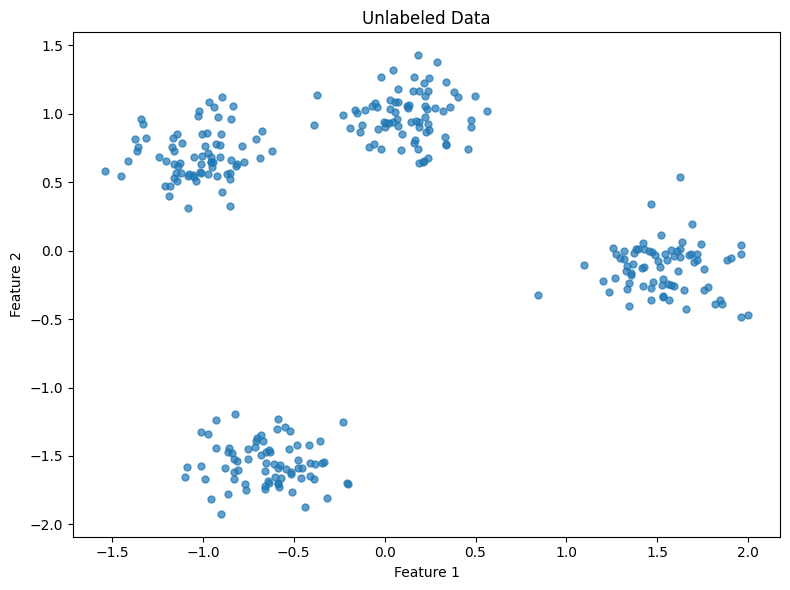

In [2]:
X,_=make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.1,
    random_state=42
)

X=StandardScaler().fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],s=25,alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unlabeled Data")
plt.tight_layout()
plt.show()


## 2. Build the hierarchy using Ward linkage

Ward linkage merges clusters while trying to minimize the increase in within-cluster variance.


In [3]:
linked=linkage(X,method="ward")
print("Linkage matrix shape:",linked.shape)


Linkage matrix shape: (299, 4)


## 3. Visualize the dendrogram


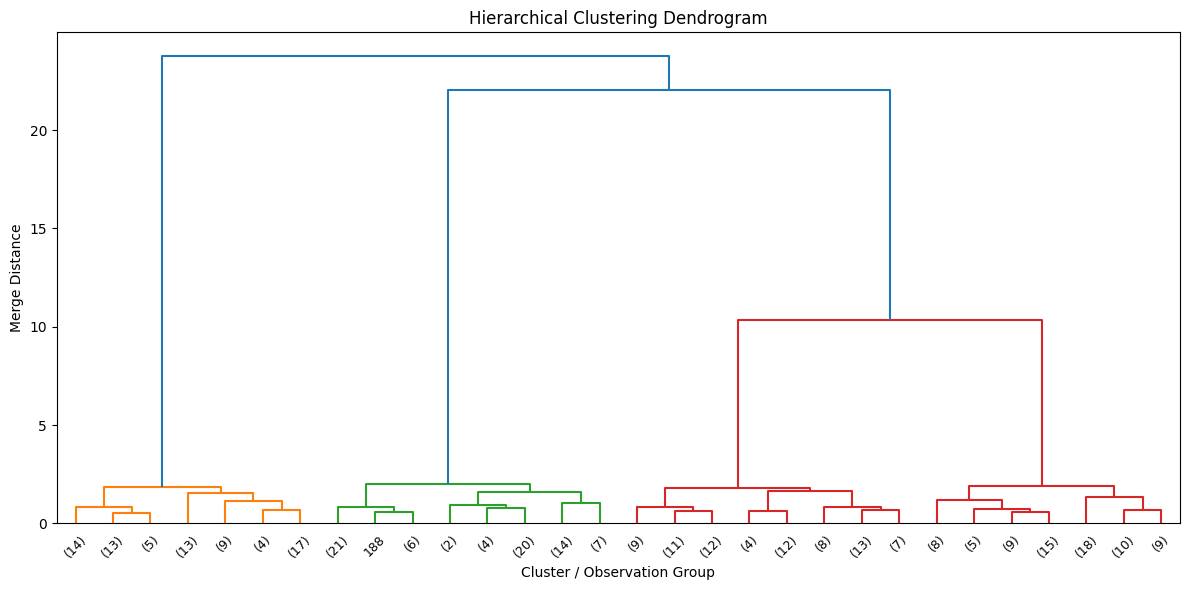

In [4]:
plt.figure(figsize=(12,6))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=9
)
plt.xlabel("Cluster / Observation Group")
plt.ylabel("Merge Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.show()


## 4. Cut the hierarchy into 4 clusters


In [5]:
model=AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels=model.fit_predict(X)

print(
    "Silhouette Score:",
    round(silhouette_score(X,labels),3)
)


Silhouette Score: 0.778


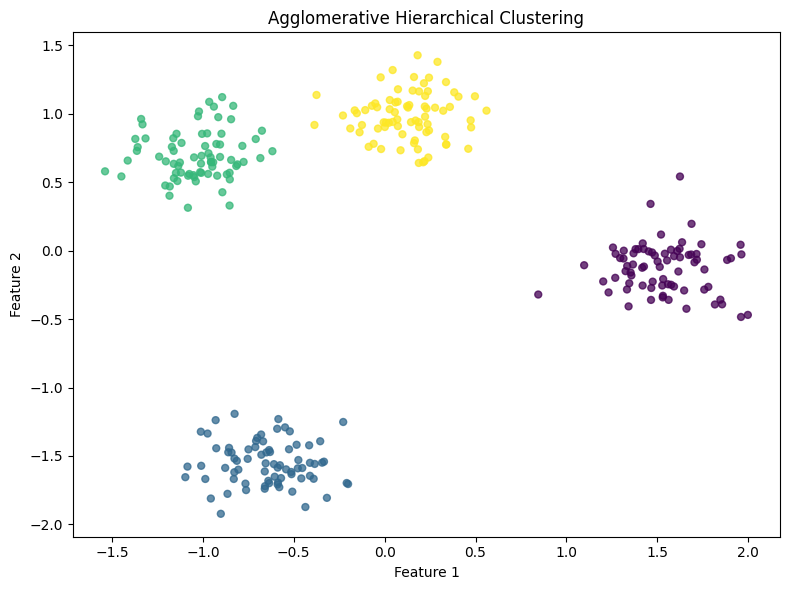

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    s=25,
    alpha=0.75
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Hierarchical Clustering")
plt.tight_layout()
plt.show()


## 5. K-Means vs Hierarchical Clustering

### K-Means
- choose K before training
- uses centroids
- repeatedly reassigns points

### Hierarchical Clustering
- builds nested groups
- uses linkage rules
- visualized with a dendrogram
- does not require centroids


## 6. Common linkage methods

**Single linkage**  
Uses the closest pair of points between clusters.

**Complete linkage**  
Uses the farthest pair.

**Average linkage**  
Uses average cross-cluster distance.

**Ward linkage**  
Chooses merges that minimize the increase in within-cluster variance.


## Enterprise intuition

Hierarchical clustering is useful when groups naturally exist at multiple levels.

Examples:
- customer segmentation
- document grouping
- product taxonomy
- behavioral segmentation
- biological data

For example:

`Customers`
→ `High Engagement / Low Engagement`

then:

`High Engagement`
→ `High Spend / Moderate Spend`

The hierarchy itself can be useful, not just the final clusters.


## Important limitations

Hierarchical clustering can become expensive for very large datasets.

It is also sensitive to:
- scaling
- linkage choice
- distance metric
- outliers

Once an agglomerative merge happens, it is not later undone.


## What does this teach?

- Hierarchical clustering builds nested clusters.
- Agglomerative clustering starts with individual observations and merges them.
- Dendrograms visualize those merges.
- Linkage determines how cluster distance is defined.
- Different cut levels produce different numbers of clusters.

> **K-Means tells us which cluster a point belongs to. Hierarchical clustering also shows how the clusters relate to each other.**


## References

- https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html
- https://doi.org/10.1080/01621459.1963.10500845
